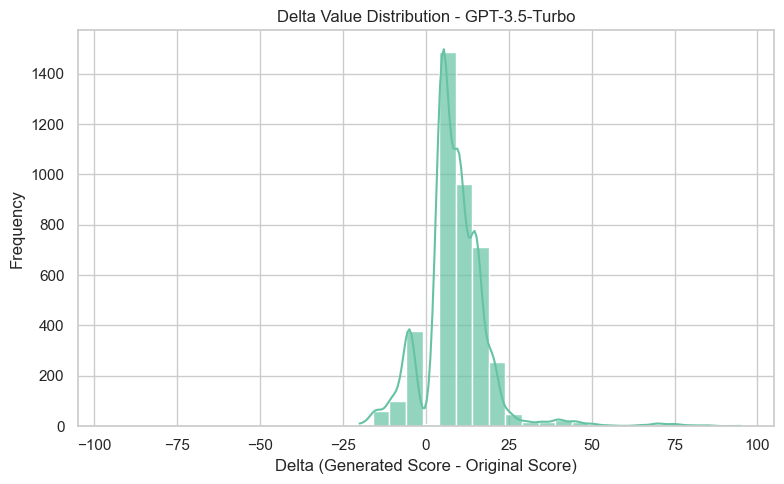

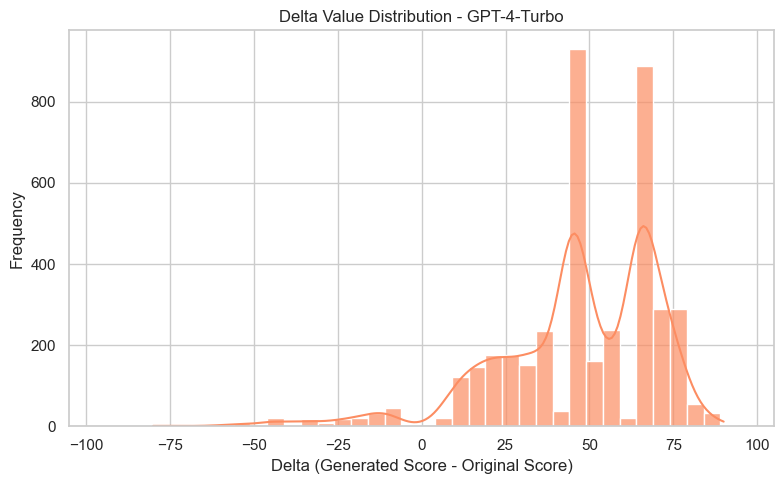

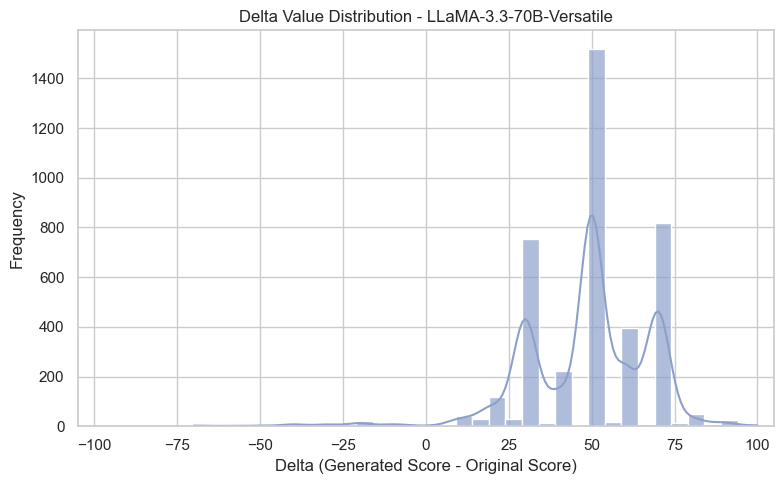

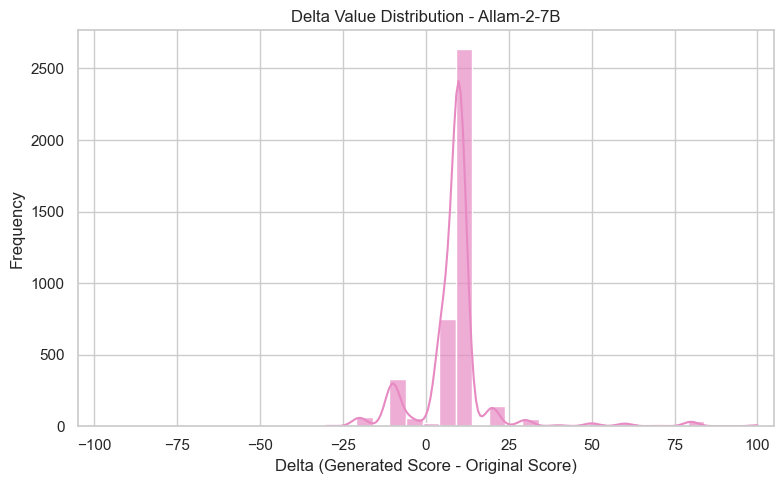

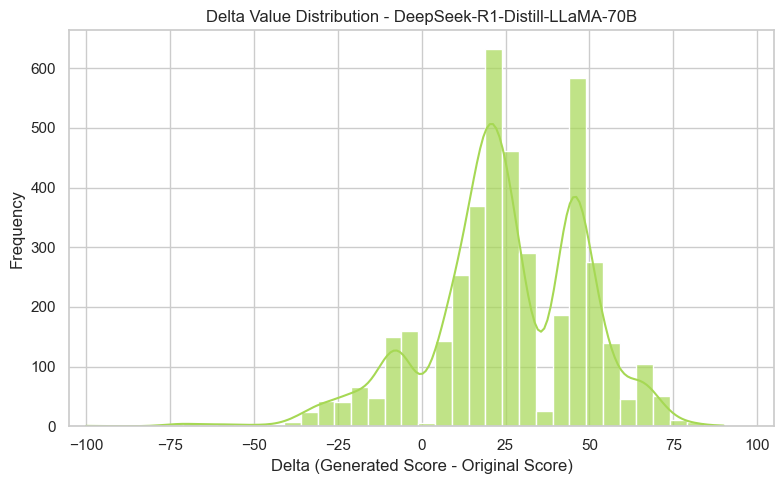

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set(style="whitegrid")

# Define file paths and color palette
file_paths = {
    "GPT-3.5-Turbo": "gpt-3.5-turbo.csv",
    "GPT-4-Turbo": "gpt-4-turbo.csv",
    "LLaMA-3.3-70B-Versatile": "llama-3.3-70b-versatile.csv",
    "Allam-2-7B": "allam-2-7b.csv",
    "DeepSeek-R1-Distill-LLaMA-70B": "deepseek-r1-distill-llama-70b.csv"
}

colors = sns.color_palette("Set2", 5)

# First, determine the global min and max delta
min_delta, max_delta = float("inf"), float("-inf")
for file_path in file_paths.values():
    try:
        df = pd.read_csv(file_path)
        min_delta = min(min_delta, df['delta'].min())
        max_delta = max(max_delta, df['delta'].max())
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

# Define consistent bin edges
bins = range(int(min_delta) - 1, int(max_delta) + 2, 5)  # bin width of 5

# Plot histograms with fixed x-axis
for idx, (model_name, file_path) in enumerate(file_paths.items()):
    try:
        df = pd.read_csv(file_path)
        plt.figure(figsize=(8, 5))
        sns.histplot(df['delta'], kde=True, color=colors[idx], bins=bins, alpha=0.7)
        plt.title(f"Delta Value Distribution - {model_name}")
        plt.xlabel("Delta (Generated Score - Original Score)")
        plt.ylabel("Frequency")
        plt.xlim(min_delta - 5, max_delta + 5)  # fixed x-axis range
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error processing {model_name} from {file_path}: {e}")


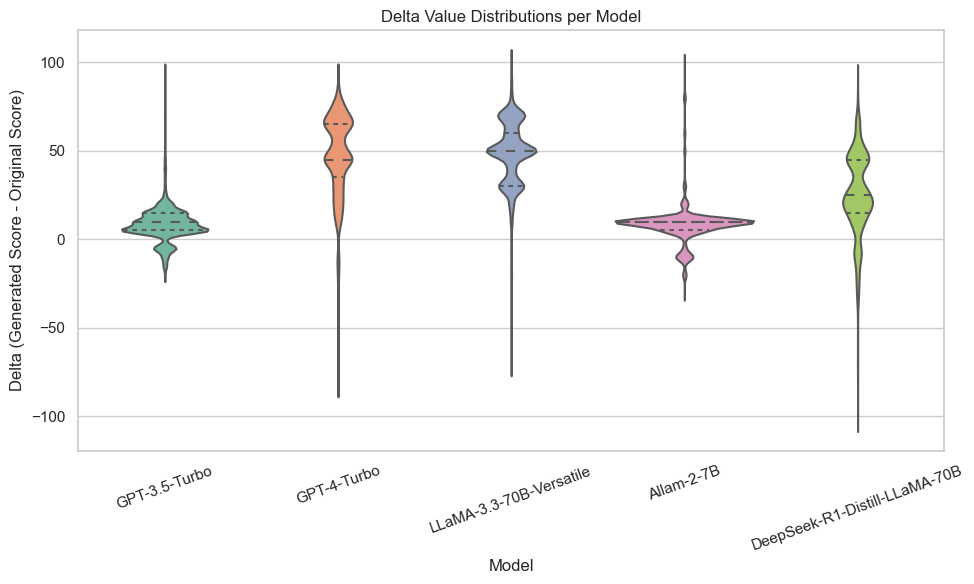

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# File paths for each model
file_paths = {
    "GPT-3.5-Turbo": "gpt-3.5-turbo.csv",
    "GPT-4-Turbo": "gpt-4-turbo.csv",
    "LLaMA-3.3-70B-Versatile": "llama-3.3-70b-versatile.csv",
    "Allam-2-7B": "allam-2-7b.csv",
    "DeepSeek-R1-Distill-LLaMA-70B": "deepseek-r1-distill-llama-70b.csv"
}

# Load and combine the data
all_data = []
for model_name, path in file_paths.items():
    try:
        df = pd.read_csv(path)
        df['Model'] = model_name
        all_data.append(df[['delta', 'Model']])
    except Exception as e:
        print(f"Failed to load {model_name}: {e}")

# Concatenate all data into a single DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# Plot violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Model', y='delta', data=combined_df, palette='Set2', inner='quartile')
plt.xticks(rotation=20)
plt.title("Delta Value Distributions per Model")
plt.ylabel("Delta (Generated Score - Original Score)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


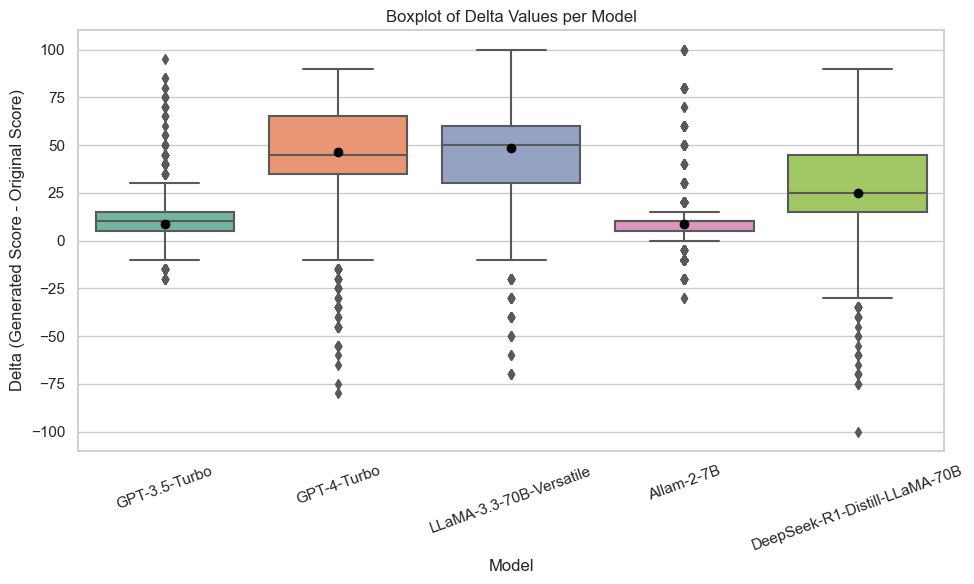

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# File paths for each model
file_paths = {
    "GPT-3.5-Turbo": "gpt-3.5-turbo.csv",
    "GPT-4-Turbo": "gpt-4-turbo.csv",
    "LLaMA-3.3-70B-Versatile": "llama-3.3-70b-versatile.csv",
    "Allam-2-7B": "allam-2-7b.csv",
    "DeepSeek-R1-Distill-LLaMA-70B": "deepseek-r1-distill-llama-70b.csv"
}

# Combine all model data
all_data = []
for model_name, path in file_paths.items():
    try:
        df = pd.read_csv(path)
        df['Model'] = model_name
        all_data.append(df[['delta', 'Model']])
    except Exception as e:
        print(f"Failed to load {model_name}: {e}")

# Combine into one DataFrame
combined_df = pd.concat(all_data, ignore_index=True)

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='delta', data=combined_df, palette='Set2', showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black"})
plt.xticks(rotation=20)
plt.title("Boxplot of Delta Values per Model")
plt.ylabel("Delta (Generated Score - Original Score)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


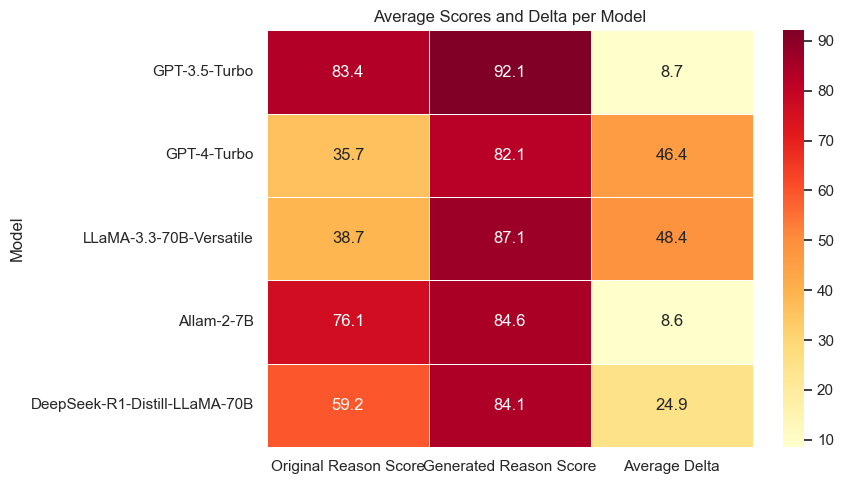

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define file paths
file_paths = {
    "GPT-3.5-Turbo": "gpt-3.5-turbo.csv",
    "GPT-4-Turbo": "gpt-4-turbo.csv",
    "LLaMA-3.3-70B-Versatile": "llama-3.3-70b-versatile.csv",
    "Allam-2-7B": "allam-2-7b.csv",
    "DeepSeek-R1-Distill-LLaMA-70B": "deepseek-r1-distill-llama-70b.csv"
}

# Collect average scores and delta
summary_data = []

for model_name, path in file_paths.items():
    try:
        df = pd.read_csv(path)
        original_avg = df['original_reason_score'].mean()
        generated_avg = df['generated_reason_score'].mean()
        delta_avg = df['delta'].mean()
        summary_data.append({
            'Model': model_name,
            'Original Reason Score': original_avg,
            'Generated Reason Score': generated_avg,
            'Average Delta': delta_avg
        })
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

# Create DataFrame for heatmap
score_df = pd.DataFrame(summary_data)
score_df.set_index('Model', inplace=True)

# Plot heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(score_df, annot=True, cmap="YlOrRd", fmt=".1f", linewidths=.5)
plt.title("Average Scores and Delta per Model")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


                           Model       Mean  Median    Std Dev
0                  GPT-3.5-Turbo   8.711251    10.0  10.528817
1                    GPT-4-Turbo  46.406325    45.0  24.073677
2        LLaMA-3.3-70B-Versatile  48.409947    50.0  19.020229
3                     Allam-2-7B   8.592226    10.0  11.778445
4  DeepSeek-R1-Distill-LLaMA-70B  24.911395    25.0  22.966374


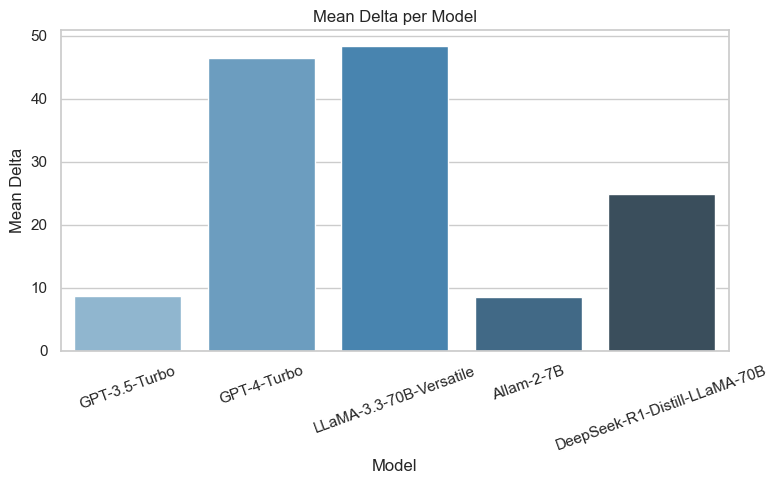

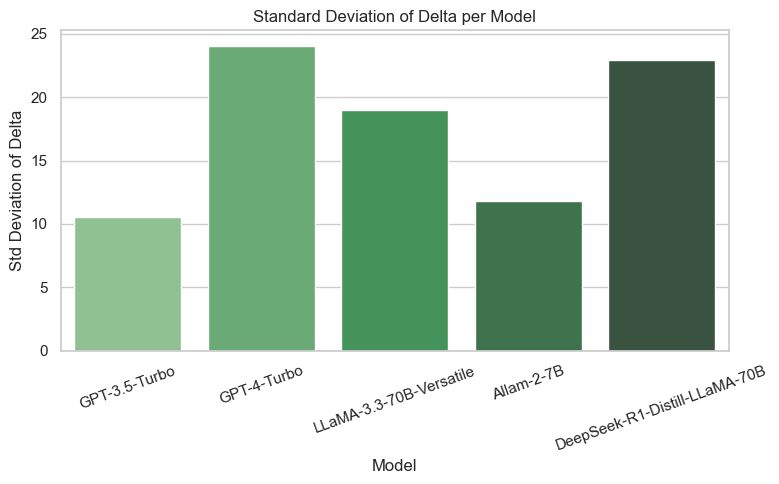

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# File paths for each model
file_paths = {
    "GPT-3.5-Turbo": "gpt-3.5-turbo.csv",
    "GPT-4-Turbo": "gpt-4-turbo.csv",
    "LLaMA-3.3-70B-Versatile": "llama-3.3-70b-versatile.csv",
    "Allam-2-7B": "allam-2-7b.csv",
    "DeepSeek-R1-Distill-LLaMA-70B": "deepseek-r1-distill-llama-70b.csv"
}

# Collect stats
summary = []

for model_name, path in file_paths.items():
    try:
        df = pd.read_csv(path)
        delta_mean = df['delta'].mean()
        delta_median = df['delta'].median()
        delta_std = df['delta'].std()
        summary.append({
            'Model': model_name,
            'Mean': delta_mean,
            'Median': delta_median,
            'Std Dev': delta_std
        })
    except Exception as e:
        print(f"Error processing {model_name}: {e}")

# Convert to DataFrame
stats_df = pd.DataFrame(summary)

# Print summary table
print(stats_df)

# Plot Mean Delta
plt.figure(figsize=(8, 5))
sns.barplot(data=stats_df, x='Model', y='Mean', palette='Blues_d')
plt.xticks(rotation=20)
plt.title('Mean Delta per Model')
plt.ylabel('Mean Delta')
plt.tight_layout()
plt.show()

# Plot Standard Deviation of Delta
plt.figure(figsize=(8, 5))
sns.barplot(data=stats_df, x='Model', y='Std Dev', palette='Greens_d')
plt.xticks(rotation=20)
plt.title('Standard Deviation of Delta per Model')
plt.ylabel('Std Deviation of Delta')
plt.tight_layout()
plt.show()
